Now let us implement GRPO in PyTorch. We will write the core components step by step.

First, the advantage computation — this is the heart of GRPO:

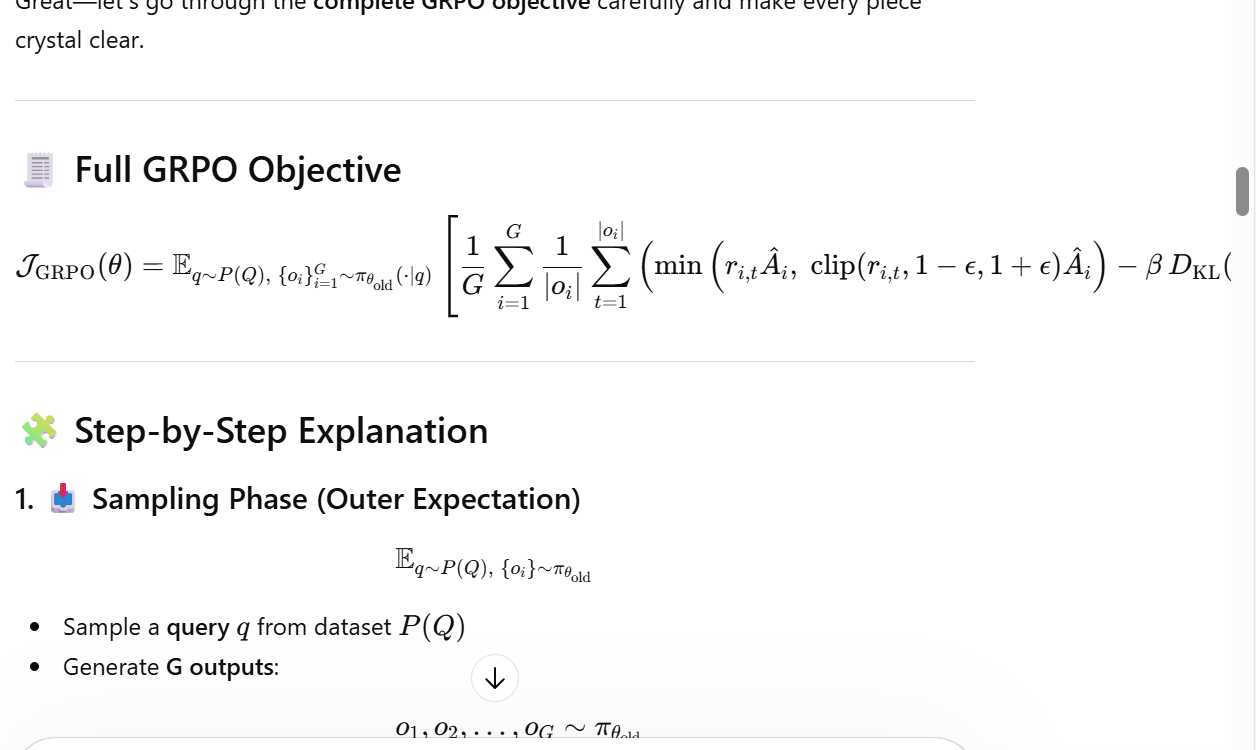

##Complete Intution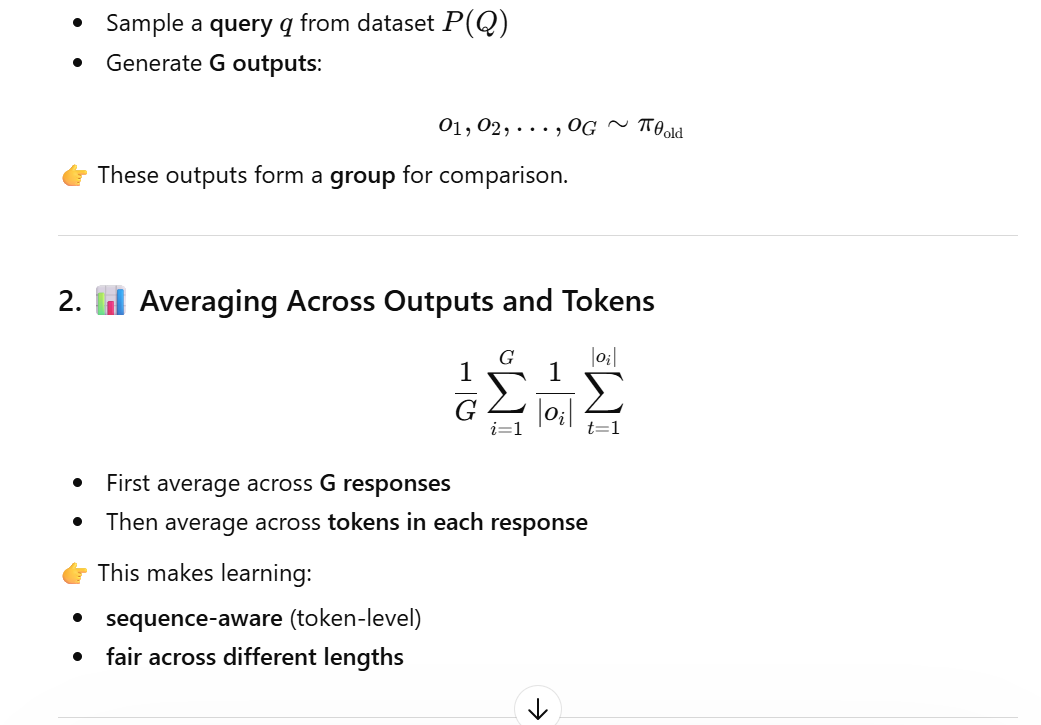

https://chatgpt.com/c/69d20ac7-9794-83ab-a0e0-26dd16503203

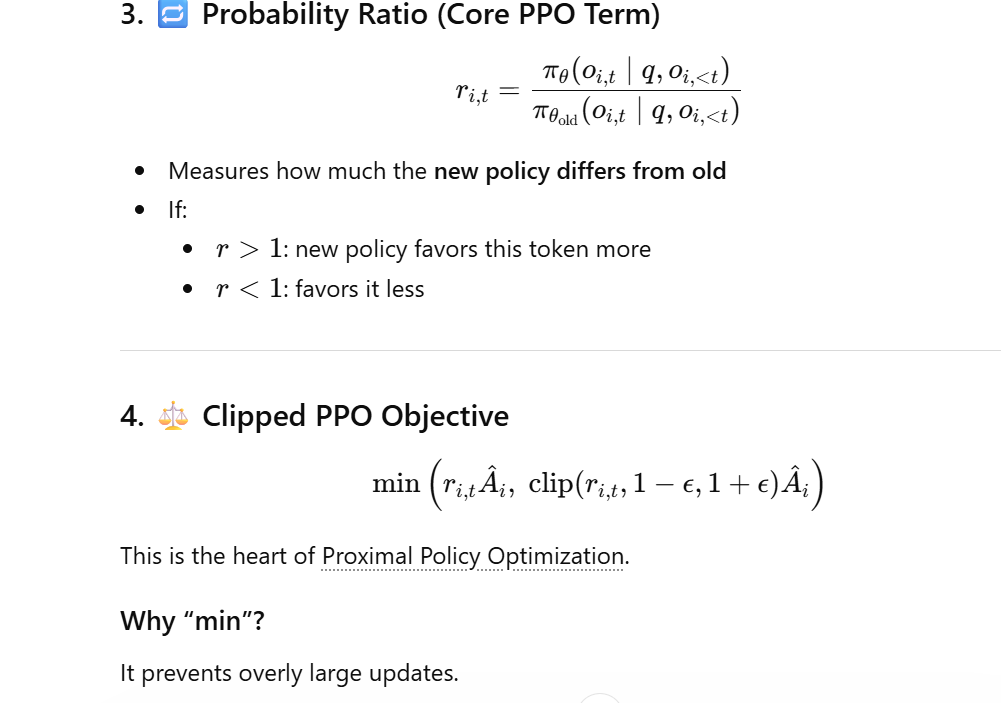

https://chatgpt.com/c/69d20ac7-9794-83ab-a0e0-26dd16503203

In [7]:
import torch

def compute_grpo_advantages(rewards, eps=1e-8):
    """
    rewards: Tensor of shape (G,) or (batch_size, G)
    returns: normalized advantages with same shape
    """
    mean = rewards.mean(dim=-1, keepdim=True)
    std = rewards.std(dim=-1, keepdim=True)

    advantages = (rewards - mean) / (std + eps)
    return advantages

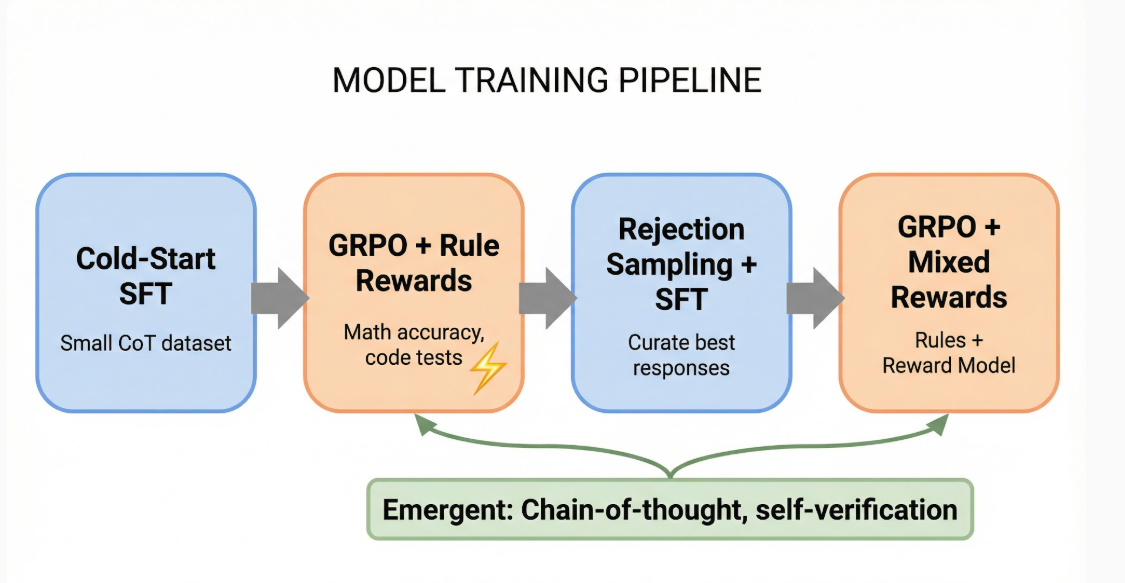

In [9]:
def compute_grpo_loss(
    log_probs: torch.Tensor,       # (G, T) log probs under current policy
    old_log_probs: torch.Tensor,   # (G, T) log probs under old policy
    ref_log_probs: torch.Tensor,   # (G, T) log probs under reference policy
    advantages: torch.Tensor,       # (G,) per-response advantages
    mask: torch.Tensor,             # (G, T) attention mask
    epsilon: float = 0.2,
    beta: float = 0.04,
) -> torch.Tensor:
    """
    Compute the GRPO loss.
    """
    # Per-token importance sampling ratio
    ratio = torch.exp(log_probs - old_log_probs)  # (G, T)

    # Expand advantages to match token dimension
    adv = advantages.unsqueeze(1)  # (G, 1) -> broadcasts to (G, T)

    # Clipped surrogate objective
    surr1 = ratio * adv
    surr2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * adv
    policy_loss = torch.min(surr1, surr2)  # (G, T)

    # KL divergence penalty (per-token)
    kl_ratio = torch.exp(ref_log_probs - log_probs)  # pi_ref / pi_theta
    kl_div = kl_ratio - torch.log(kl_ratio) - 1.0    # (G, T)

    # Combine: maximize policy objective, minimize KL divergence
    per_token_loss = policy_loss - beta * kl_div  # (G, T)

    # Average over valid tokens (using mask), then over group
    per_response = (per_token_loss * mask).sum(dim=1) / mask.sum(dim=1)
    loss = -per_response.mean()  # Negate because we minimize

    return loss

In [11]:
def grpo_training_step(
    policy_model, ref_model, reward_model, tokenizer,
    prompts, optimizer, G=8, epsilon=0.2, beta=0.04
):
    """One GRPO training step."""
    policy_model.train()
    total_loss = 0.0

    for prompt in prompts:
        # Step 1: Generate G completions from the OLD policy
        input_ids = tokenizer(prompt, return_tensors="pt").input_ids
        completions = []
        for _ in range(G):
            with torch.no_grad():
                output = policy_model.generate(
                    input_ids, max_new_tokens=256,
                    do_sample=True, temperature=1.0
                )
            completions.append(output)

        # Step 2: Score each completion with the reward model
        rewards = torch.tensor([
            reward_model.score(prompt, tokenizer.decode(c[0]))
            for c in completions
        ])

        # Step 3: Compute group-relative advantages
        advantages = compute_grpo_advantages(rewards)

        # Step 4: Compute log probs under current, old, ref policies
        # (simplified — real impl would batch this)
        log_probs = get_log_probs(policy_model, completions)
        with torch.no_grad():
            old_log_probs = log_probs.detach()
            ref_log_probs = get_log_probs(ref_model, completions)

        # Step 5: Compute GRPO loss
        mask = create_completion_mask(completions, input_ids)
        loss = compute_grpo_loss(
            log_probs, old_log_probs, ref_log_probs,
            advantages, mask, epsilon, beta
        )

        loss.backward()
        total_loss += loss.item()

    optimizer.step()
    optimizer.zero_grad()

    return total_loss / len(prompts)